In [ ]:
import socket
import time
import random
import numpy as np
import threading
from collections import deque

HOST = 'localhost'
PORT = 8000
NUM_ORDERS = 100000
NUM_THREADS = 5
PIPELINE_DEPTH = 64

# Socket and synchronization tuning for concurrency tests.
SOCKET_TIMEOUT_S = 5.0
BARRIER_TIMEOUT_S = 20.0
RECV_BYTES = 4096

thread_rtts = [[] for _ in range(NUM_THREADS)]
thread_type_rtts = [{"NEW": [], "MODIFY": [], "CANCEL": []} for _ in range(NUM_THREADS)]
thread_errors = [None for _ in range(NUM_THREADS)]
thread_start_ns = [0 for _ in range(NUM_THREADS)]
thread_end_ns = [0 for _ in range(NUM_THREADS)]

# Split work exactly across threads so total generated orders equals NUM_ORDERS.
thread_order_counts = [NUM_ORDERS // NUM_THREADS] * NUM_THREADS
for i in range(NUM_ORDERS % NUM_THREADS):
    thread_order_counts[i] += 1

def generate_thread_requests(thread_id, num_orders):
    rng = random.Random(12345 + thread_id)
    order_ids = []
    next_order_id = thread_id * 1_000_000 + 1
    requests = []

    for _ in range(num_orders):
        order_type = rng.choices(["NEW", "MODIFY", "CANCEL"], weights=[0.7, 0.2, 0.1])[0]
        symbol = rng.choice(["NVDA", "AAPL", "TSLA"])
        side_tag = "1" if rng.choice(["BUY", "SELL"]) == "BUY" else "2"

        if order_type == "NEW" or not order_ids:
            order = (
                f"8=FIX.4.2|35=D|11={next_order_id}|55={symbol}|54={side_tag}|"
                f"44={rng.randint(90000, 110000)}|38={rng.randint(1, 10)}|"
            )
            order_ids.append(next_order_id)
            next_order_id += 1
        elif order_type == "MODIFY":
            oid = rng.choice(order_ids)
            order = (
                f"8=FIX.4.2|35=G|11={oid}|55={symbol}|54={side_tag}|"
                f"44={rng.randint(90000, 110000)}|38={rng.randint(1, 10)}|"
            )
        else:  # CANCEL
            oid = rng.choice(order_ids)
            order = f"8=FIX.4.2|35=F|11={oid}|"
            order_ids.remove(oid)

        requests.append((order_type, order.encode()))

    return requests

# Pre-generate all thread requests outside timed section.
thread_requests = [
    generate_thread_requests(thread_id, thread_order_counts[thread_id])
    for thread_id in range(NUM_THREADS)
]

# Only synchronize starts when running true multi-thread tests.
use_sync_start = NUM_THREADS > 1
connected_barrier = threading.Barrier(NUM_THREADS) if use_sync_start else None
start_barrier = threading.Barrier(NUM_THREADS) if use_sync_start else None

def thread_worker(thread_id):
    try:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.settimeout(SOCKET_TIMEOUT_S)
            s.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
            s.connect((HOST, PORT))

            if use_sync_start:
                connected_barrier.wait(timeout=BARRIER_TIMEOUT_S)
                start_barrier.wait(timeout=BARRIER_TIMEOUT_S)

            thread_start_ns[thread_id] = time.perf_counter_ns()
            pending_send_ns = deque()
            pending_types = deque()
            recv_buffer = ""

            def drain_responses():
                nonlocal recv_buffer
                chunk = s.recv(RECV_BYTES)
                if not chunk:
                    raise RuntimeError("socket closed while awaiting responses")
                recv_buffer += chunk.decode("ascii", errors="ignore")

                line_end = recv_buffer.find("\n")
                while line_end != -1 and pending_send_ns:
                    _line = recv_buffer[:line_end]
                    recv_buffer = recv_buffer[line_end + 1:]
                    t0 = pending_send_ns.popleft()
                    typ = pending_types.popleft()
                    t1 = time.perf_counter_ns()
                    rtt_us = (t1 - t0) // 1000
                    thread_rtts[thread_id].append(rtt_us)
                    thread_type_rtts[thread_id][typ].append(rtt_us)
                    line_end = recv_buffer.find("\n")

            for order_type, msg in thread_requests[thread_id]:
                while len(pending_send_ns) >= PIPELINE_DEPTH:
                    drain_responses()

                s.sendall(msg + b"\n")
                pending_send_ns.append(time.perf_counter_ns())
                pending_types.append(order_type)

            while pending_send_ns:
                drain_responses()

            thread_end_ns[thread_id] = time.perf_counter_ns()
    except Exception as e:
        thread_errors[thread_id] = str(e)

threads = []
test_start_ns = time.perf_counter_ns()
for i in range(NUM_THREADS):
    t = threading.Thread(target=thread_worker, args=(i,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()

test_end_ns = time.perf_counter_ns()
total_time_s = (test_end_ns - test_start_ns) / 1e9

# Combine results
all_rtts = [rtt for sublist in thread_rtts for rtt in sublist]
all_type_rtts = {"NEW": [], "MODIFY": [], "CANCEL": []}
for d in thread_type_rtts:
    for typ in all_type_rtts:
        all_type_rtts[typ].extend(d[typ])

completed_orders = len(all_rtts)
throughput = completed_orders / total_time_s if total_time_s > 0 else float("inf")
failed_threads = sum(1 for err in thread_errors if err is not None)

# Concurrency sanity checks: if windows overlap, your client is issuing concurrent load.
valid_starts = [x for x in thread_start_ns if x > 0]
valid_ends = [x for x in thread_end_ns if x > 0]
thread_overlap_window_s = 0.0
if valid_starts and valid_ends:
    thread_overlap_window_s = (max(valid_ends) - min(valid_starts)) / 1e9

print(f"Threads: {NUM_THREADS}")
print(f"Pipeline depth: {PIPELINE_DEPTH}")
print(f"Generated orders: {sum(thread_order_counts)}")
print(f"Total orders sent: {completed_orders}")
print(f"Failed threads: {failed_threads}")
print(f"Mean RTT: {np.mean(all_rtts):.2f}us" if all_rtts else "Mean RTT: n/a")
print(f"Throughput: {throughput:.2f} orders/sec")
print(f"Concurrent test window (client-side): {thread_overlap_window_s:.4f}s")

for idx, err in enumerate(thread_errors):
    if err is not None:
        print(f"Thread {idx} error: {err}")

Threads: 5
Generated orders: 100000
Total orders sent: 100000
Failed threads: 0
Mean RTT: 503.53us
Throughput: 9827.11 orders/sec
Concurrent test window (client-side): 10.1719s


Connect to Server and generate random orders

Throughput: 9909.42 orders/second
ALL: count=100000, mean=499.44us, p50=368.00us, p95=1261.00us, p99=1800.01us, max=16333.00us
NEW: count=70044, mean=500.71us, p50=367.00us, p95=1260.00us, p99=1802.57us, max=16333.00us
MODIFY: count=19940, mean=497.10us, p50=372.00us, p95=1261.00us, p99=1799.00us, max=6618.00us
CANCEL: count=10016, mean=495.24us, p50=363.00us, p95=1275.25us, p99=1789.70us, max=8566.00us


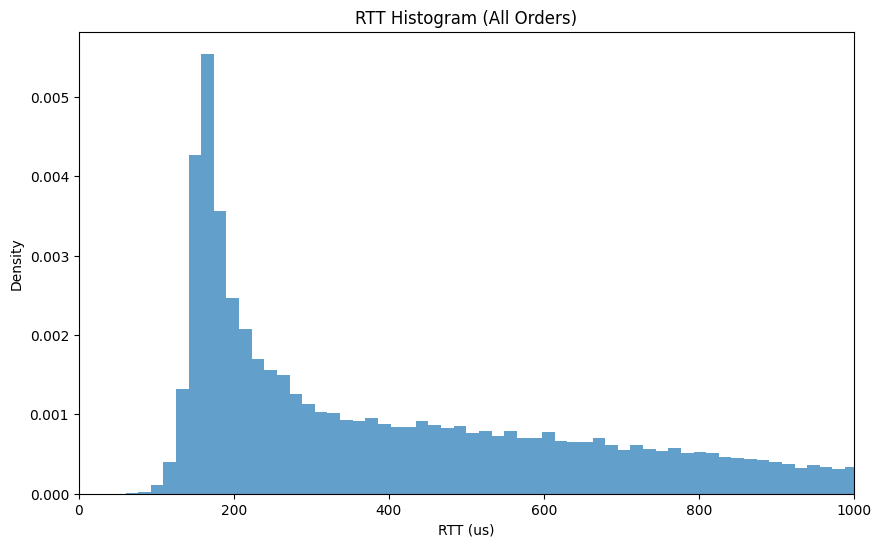

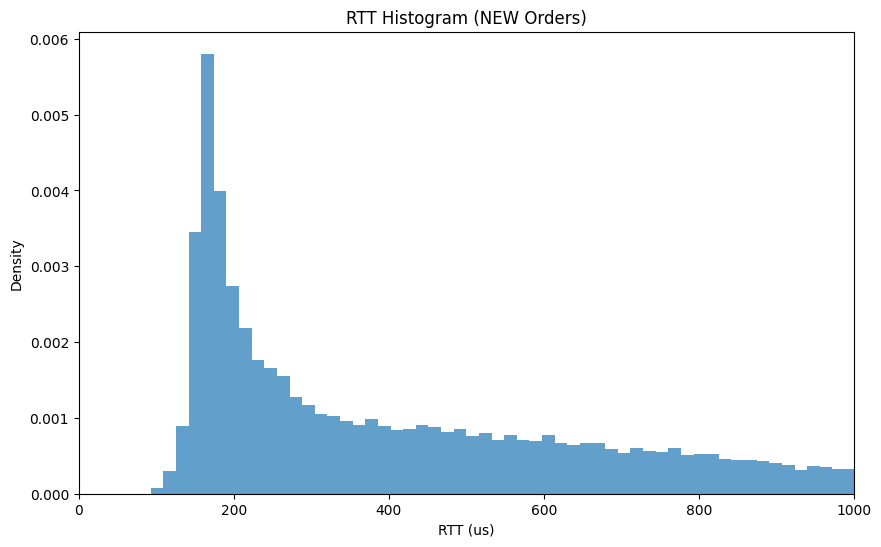

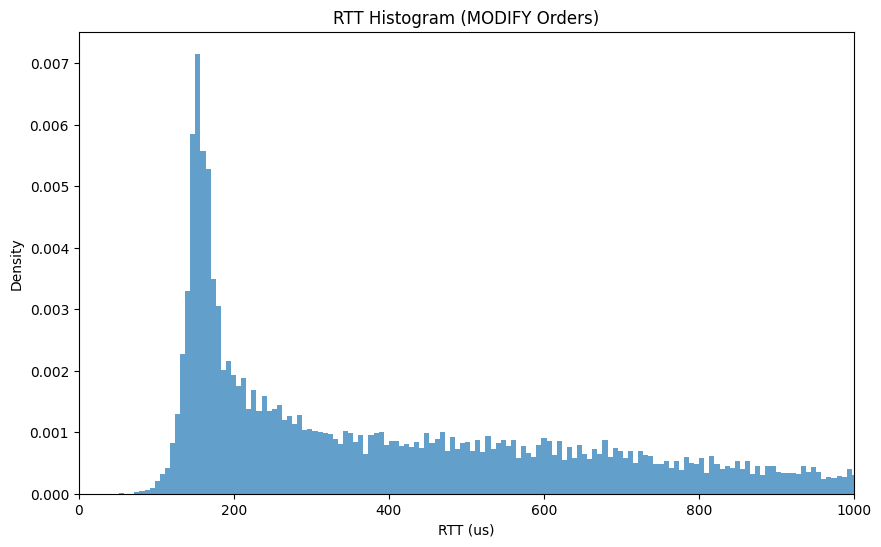

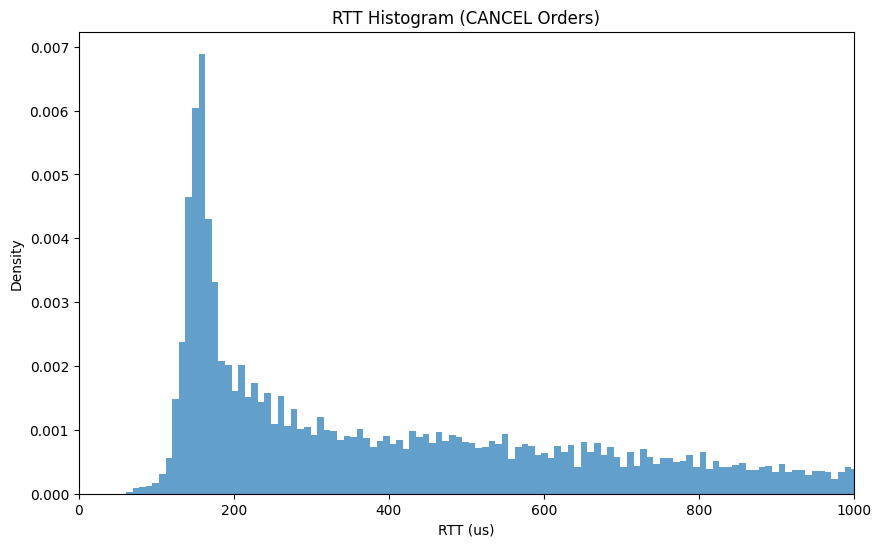

In [5]:
# Print metrics
print(f"Throughput: {throughput:.2f} orders/second")

import numpy as np
import matplotlib.pyplot as plt

def print_stats(name, data):
    arr = np.array(data)
    if len(arr) == 0:
        print(f"{name}: count=0 (no samples)")
        return
    print(
        f"{name}: count={len(arr)}, mean={arr.mean():.2f}us, "
        f"p50={np.percentile(arr,50):.2f}us, "
        f"p95={np.percentile(arr,95):.2f}us, "
        f"p99={np.percentile(arr,99):.2f}us, max={arr.max():.2f}us"
    )

print_stats("ALL", all_rtts)
for typ in all_type_rtts:
    print_stats(typ, all_type_rtts[typ])

if len(all_rtts) > 0:
    # Histogram for all RTTs
    plt.figure(figsize=(10, 6))
    plt.hist(all_rtts, bins=1000, alpha=0.7, density=True)
    plt.title("RTT Histogram (All Orders)")
    plt.xlabel("RTT (us)")
    plt.ylabel("Density")
    plt.xlim(0, 1000)
    plt.yscale('linear')
    plt.show()

# Histogram for each type
for typ in all_type_rtts:
    if len(all_type_rtts[typ]) == 0:
        continue
    plt.figure(figsize=(10, 6))
    plt.hist(all_type_rtts[typ], bins=1000, alpha=0.7, density=True)
    plt.title(f"RTT Histogram ({typ} Orders)")
    plt.xlabel("RTT (us)")
    plt.ylabel("Density")
    plt.xlim(0, 1000)
    plt.show()